Load the data

In [4]:
#  Loading the data with all 200 features (for 200x200 data) - alternative loading method

from scipy.io import loadmat
import torch
import numpy as np

filepath = "Input Data\FC1.mat"
fc_mat = loadmat(filepath)
fc_mat = fc_mat['FC1']  # Extract the FC1 variable from the loaded .mat file

print(fc_mat.shape)  # Should print (200, 200, N_subjects)

fc_mat_inv = np.transpose(fc_mat, (2, 0, 1))  # Transpose to (N_subjects, 200, 200)
fc_mat_inv = fc_mat_inv[:, None, :, :]  # Add a channel dimension to get (N_subjects, 1, 200, 200)
print(fc_mat_inv.shape)  # Should print (N_subjects, 1, 200, 200)

X = torch.from_numpy(fc_mat_inv).float()  # Convert to PyTorch tensor
print("Data shape:", X.shape)  # Should print (N_subjects, 1, 200, 200)

# Expected shape is (Batch size, channels, height, width)

<>:7: SyntaxWarning: "\F" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\F"? A raw string is also an option.
<>:7: SyntaxWarning: "\F" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\F"? A raw string is also an option.
C:\Users\oddafo\AppData\Local\Temp\ipykernel_14552\2830987651.py:7: SyntaxWarning: "\F" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\F"? A raw string is also an option.
  filepath = "Input Data\FC1.mat"


(200, 200, 72)
(72, 1, 200, 200)
Data shape: torch.Size([72, 1, 200, 200])


In [5]:
def check_zero_mean_unit_range(data, atol=1e-5):
    if hasattr(data, "detach"):
        arr = data.detach().cpu().numpy()
    else:
        arr = np.asarray(data)

    mean_val = arr.mean()
    min_val = arr.min()
    max_val = arr.max()

    is_zero_mean = np.isclose(mean_val, 0.0, atol=atol)
    has_minus_one = np.isclose(min_val, -1.0, atol=atol)
    has_plus_one = np.isclose(max_val, 1.0, atol=atol)

    print(f"Doing checks for zero mean and unit range:")
    print(f"mean: {mean_val:.6f}")
    print(f"standard deviation: {arr.std():.6f}")
    print(f"min:  {min_val:.6f}")
    print(f"max:  {max_val:.6f}")
    print(f"zero mean: {is_zero_mean}")
    print(f"min == -1: {has_minus_one}")
    print(f"max ==  1: {has_plus_one}")

    return is_zero_mean and has_minus_one and has_plus_one

# Example:
# check_zero_mean_unit_range(X)

def z_normalize(data, eps=1e-8):
    if hasattr(data, "detach"):
        mean = data.mean(dim=(1, 2, 3), keepdim=True)
        std = data.std(dim=(1, 2, 3), keepdim=True, unbiased=False).clamp_min(eps)
        return (data - mean) / std

    arr = np.asarray(data)
    mean = arr.mean(axis=tuple(range(1, arr.ndim)), keepdims=True)
    std = arr.std(axis=tuple(range(1, arr.ndim)), keepdims=True)
    std = np.maximum(std, eps)
    return (arr - mean) / std


In [8]:
check_zero_mean_unit_range(X)
z_normalized_X = z_normalize(X)
check_zero_mean_unit_range(z_normalized_X)

Doing checks for zero mean and unit range:
mean: 0.008007
min:  -0.825187
max:  1.000000
zero mean: False
min == -1: False
max ==  1: True
Doing checks for zero mean and unit range:
mean: -0.000000
min:  -2.785055
max:  3.682692
zero mean: True
min == -1: False
max ==  1: False


False

In [6]:
import pandas as pd

def read_csv_and_column_min_max(csv_path):
    df = pd.read_csv(csv_path)
    min_max = pd.DataFrame({
        "min": df.min(numeric_only=True),
        "max": df.max(numeric_only=True)
    })
    return df, min_max

# Example:
# df, column_stats = read_csv_and_column_min_max("your_file.csv")
# print(column_stats)

In [3]:
csv_path = "C:\Mats og Odd Arne\Prosjektoppgave\ISC_data\Beh.csv"

df, column_stats = read_csv_and_column_min_max(csv_path)
for value in  column_stats.itertuples():
    print(f"{value.Index}: min={value.min}, max={value.max}")

Subject: min=11001.0, max=12334.0
Group: min=1.0, max=2.0
Age: min=19.0, max=82.0
Order: min=1.0, max=141.0
Sex: min=1.0, max=2.0
Relationshipstatus: min=1.0, max=5.0
Avg_Sleep: min=4.0, max=10.5
EnglishYearsSpeaking: min=0.0, max=43.0
YearsEducation: min=0.0, max=29.0
PsychDiagnosis: min=0.0, max=1.0
Medicine: min=0.0, max=1.0
NeuroImpairment: min=0.0, max=1.0
EV_base: min=1.0, max=9.0
EV_neu: min=1.0, max=9.0
EV_neg: min=1.0, max=9.0
ER_base: min=1.0, max=9.0
ER_neu: min=1.0, max=9.0
ER_neg: min=1.0, max=9.0
dEV_neu: min=-4.0, max=6.0
dEV_neg: min=-8.0, max=6.0
dER_neu: min=-3.0, max=5.0
dER_neg: min=-4.0, max=8.0
Q1_DASSDepression: min=0.0, max=18.0
Q1_DASSAnxiety: min=0.0, max=14.0
Q1_DASSStress: min=0.0, max=19.0
Q2_DERSScore: min=47.0, max=119.0
Q2_DERSNONACCEPT: min=6.0, max=23.0
Q2_DERSGOALS: min=5.0, max=25.0
Q2_DERSIMPULSE: min=6.0, max=22.0
Q2_DERSAWARENESS: min=6.0, max=28.0
Q2_DERSSTRATEGIES: min=8.0, max=31.0
Q2_DERSCLARITY: min=5.0, max=21.0
Q3_GHQ28Score: min=31.0, max=

<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\oddafo\AppData\Local\Temp\ipykernel_4236\3478438818.py:1: SyntaxWarning: invalid escape sequence '\M'
  csv_path = "C:\Mats og Odd Arne\Prosjektoppgave\ISC_data\Beh.csv"


In [19]:
import scipy.io as sio
import pandas as pd
import numpy as np
import re


def extract_id_from_mat_name(text):
    """
    Extract subject ID from text between 'sub-' and '-task'.
    Example:
        'something_sub-0123-task-rest_run-1_bold.mat' -> '0123'
    """
    start_str = "sub-"
    end_str = "_task"
    
    match = re.search(r"sub-(.*?)_task", text)
    return match.group(1).strip() if match else None


def normalize_id(x, remove_leading_zeros=False):
    """
    Convert IDs to a common format so strings/numbers compare correctly.
    """
    x = str(x).strip()

    # Convert things like 123.0 -> 123
    if re.fullmatch(r"\d+\.0", x):
        x = x[:-2]

    if remove_leading_zeros and x.isdigit():
        x = str(int(x))

    return x


def flatten_subject_names(arr):
    """
    Flatten MATLAB subject_names into a list of strings.
    Works for common scipy.io.loadmat outputs.
    """
    arr = np.asarray(arr)
    values = []

    for item in arr.flat:
        if isinstance(item, np.ndarray):
            if item.size == 1:
                values.append(str(item.item()).strip())
            else:
                values.append("".join(str(x) for x in item.flat).strip())
        else:
            values.append(str(item).strip())

    return values


def load_ids_from_mat(mat_file, remove_leading_zeros=False):
    """
    Load subject IDs from subject_names in a .mat file.
    """
    mat_data = sio.loadmat(mat_file)

    if "subject_names" not in mat_data:
        raise ValueError(f"'subject_names' not found in {mat_file}")

    subject_names = flatten_subject_names(mat_data["subject_names"])

    ids = set()
    for name in subject_names:
        sid = extract_id_from_mat_name(name)
        if sid is not None:
            ids.add(normalize_id(sid, remove_leading_zeros))

    return ids


def load_ids_from_csv(csv_file, remove_leading_zeros=False):
    """
    Load IDs from a CSV file.
    This searches all cells and keeps values that look like IDs.
    If your CSV has a specific ID column, I can make this stricter.
    """
    df = pd.read_csv(csv_file)
    ids = set()

    for col in df.columns:
        for value in df[col].dropna():
            val = normalize_id(value, remove_leading_zeros)
            ids.add(val)

    return ids


def compare_two_mats_against_csv(mat_file_1, mat_file_2, csv_file, remove_leading_zeros=False):
    """
    Compare the COMBINED subject IDs from two MAT files against one CSV file.
    Returns:
        only_in_combined_mats
        only_in_csv
    """
    mat_ids_1 = load_ids_from_mat(mat_file_1, remove_leading_zeros)
    mat_ids_2 = load_ids_from_mat(mat_file_2, remove_leading_zeros)

    combined_mat_ids = mat_ids_1.union(mat_ids_2)
    csv_ids = load_ids_from_csv(csv_file, remove_leading_zeros)

    only_in_combined_mats = sorted(combined_mat_ids - csv_ids)
    only_in_csv = sorted(csv_ids - combined_mat_ids)

    print(f"\nTotal IDs in {mat_file_1}: {len(mat_ids_1)}")
    print(f"Total IDs in {mat_file_2}: {len(mat_ids_2)}")
    print(f"Total unique IDs in combined MAT files: {len(combined_mat_ids)}")
    print(f"Total IDs in CSV: {len(csv_ids)}")

    print("\nIDs in combined MAT files but not in CSV:")
    for sid in only_in_combined_mats:
        print(sid)

    print("\nIDs in CSV but not in combined MAT files:")
    for sid in only_in_csv:
        print(sid)


    return only_in_combined_mats, only_in_csv

In [21]:
Included_subjects_path = "Dummy Test Data\\Included subjects.csv"
matlab_path_young = "Input Data\\YoungAge_combined_run1_400_noZ.mat"
matlab_path_old = "Input Data\\OldAge_combined_run1_400_noZ.mat"


missing = compare_two_mats_against_csv(
    mat_file_1=matlab_path_young,
    mat_file_2=matlab_path_old,
    csv_file=Included_subjects_path
)

print("\nSummary of missing IDs:")
print(f"IDs in combined MAT files but not in CSV: {len(missing[0])}")
print(f"IDs in CSV but not in combined MAT files: {len(missing[1])}")


Total IDs in Input Data\YoungAge_combined_run1_400_noZ.mat: 72
Total IDs in Input Data\OldAge_combined_run1_400_noZ.mat: 69
Total unique IDs in combined MAT files: 141
Total IDs in CSV: 140

IDs in combined MAT files but not in CSV:
12179

IDs in CSV but not in combined MAT files:

Summary of missing IDs:
IDs in combined MAT files but not in CSV: 1
IDs in CSV but not in combined MAT files: 0


In [25]:
def check_missing_id_location(missing_id, mat_file_1, mat_file_2, csv_file,
                              id_column=None, remove_leading_zeros=False):
    """
    Check which dataset contains the given missing ID.
    """
    missing_id = normalize_id(missing_id, remove_leading_zeros)

    ids_mat_1 = load_ids_from_mat(mat_file_1, remove_leading_zeros)
    ids_mat_2 = load_ids_from_mat(mat_file_2, remove_leading_zeros)
    ids_csv = load_ids_from_csv(csv_file, remove_leading_zeros)

    in_mat_1 = missing_id in ids_mat_1
    in_mat_2 = missing_id in ids_mat_2
    in_csv = missing_id in ids_csv

    print(f"ID {missing_id}:")
    print(f"- In {mat_file_1}: {in_mat_1}")
    print(f"- In {mat_file_2}: {in_mat_2}")
    print(f"- In {csv_file}: {in_csv}")

    return {
        mat_file_1: in_mat_1,
        mat_file_2: in_mat_2,
        csv_file: in_csv
    }

def check_single_missing_id(mat_file_1, mat_file_2, csv_file,
                            id_column=None, remove_leading_zeros=False):
    ids_mat_1 = load_ids_from_mat(mat_file_1, remove_leading_zeros)
    ids_mat_2 = load_ids_from_mat(mat_file_2, remove_leading_zeros)
    ids_csv = load_ids_from_csv(csv_file, id_column, remove_leading_zeros)

    combined_mat_ids = ids_mat_1.union(ids_mat_2)
    symmetric_diff = combined_mat_ids.symmetric_difference(ids_csv)

    if len(symmetric_diff) != 1:
        raise ValueError(f"Expected exactly one missing ID, found {len(symmetric_diff)}: {sorted(symmetric_diff)}")

    missing_id = next(iter(symmetric_diff))

    return check_missing_id_location(
        missing_id,
        mat_file_1,
        mat_file_2,
        csv_file,
        id_column=id_column,
        remove_leading_zeros=remove_leading_zeros
    )

In [28]:
check_missing_id_location(
    missing_id=11113,  # Replace with the actual missing ID you want to check
    mat_file_1=matlab_path_young,
    mat_file_2=matlab_path_old,
    csv_file=Included_subjects_path
)

ID 11113:
- In Input Data\YoungAge_combined_run1_400_noZ.mat: True
- In Input Data\OldAge_combined_run1_400_noZ.mat: False
- In Dummy Test Data\Included subjects.csv: True


{'Input Data\\YoungAge_combined_run1_400_noZ.mat': True,
 'Input Data\\OldAge_combined_run1_400_noZ.mat': False,
 'Dummy Test Data\\Included subjects.csv': True}

In [36]:
import scipy.io as sio
import numpy as np
import re


def remove_one_subject_from_mat(mat_file, output_file, subject_id, data_key):
    """
    Remove one subject from a .mat dataset using the subject ID.

    Parameters
    ----------
    mat_file : str
        Input .mat file
    output_file : str
        Output .mat file
    subject_id : str or int
        Subject ID to remove
    data_key : str
        Key for the FC data, e.g. 'run1_data' or 'run2_data'
    """

    subject_id = str(subject_id).strip()
    mat = sio.loadmat(mat_file)

    subject_names_raw = mat["subject_names"].flatten()
    subject_names = []

    for x in subject_names_raw:
        if isinstance(x, np.ndarray):
            subject_names.append(str(x.item()))
        else:
            subject_names.append(str(x))

    subject_ids = []
    for name in subject_names:
        match = re.search(r"sub-(.*?)_task", name)
        subject_ids.append(match.group(1) if match else None)

    if subject_id not in subject_ids:
        raise ValueError(f"Subject ID {subject_id} not found in {mat_file}")

    remove_idx = subject_ids.index(subject_id)
    keep_idx = [i for i in range(len(subject_ids)) if i != remove_idx]

    new_subject_names = np.array(subject_names, dtype=object)[keep_idx]
    new_data = mat[data_key][keep_idx]

    sio.savemat(output_file, {
        "subject_names": new_subject_names,
        data_key: new_data
    })

    print(f"Removed subject {subject_id} from {mat_file}")
    print(f"Saved cleaned file to {output_file}")

import pandas as pd

def remove_one_subject_from_csv(csv_file, output_file, subject_id, id_column):
    subject_id = str(subject_id).strip()
    df = pd.read_csv(csv_file)
    df = df[df[id_column].astype(str).str.strip() != subject_id]
    df.to_csv(output_file, index=False)
    print(f"Removed subject {subject_id} from {csv_file}")
    print(f"Saved cleaned file to {output_file}")

In [34]:
missing_id = "11113"

remove_one_subject_from_mat(
    "Input Data\\YoungAge_combined_run1_400_noZ.mat",
    "Input Data\\YoungAge_combined_run1_400_noZ_clean.mat",
    missing_id,
    data_key="run1_data"
)

remove_one_subject_from_mat(
    "Input Data\\YoungAge_combined_run2_400_noZ.mat",
    "Input Data\\YoungAge_combined_run2_400_noZ_clean.mat",
    missing_id,
    data_key="run2_data"
)

Removed subject 11113 from Input Data\YoungAge_combined_run1_400_noZ.mat
Saved cleaned file to Input Data\YoungAge_combined_run1_400_noZ_clean.mat
Removed subject 11113 from Input Data\YoungAge_combined_run2_400_noZ.mat
Saved cleaned file to Input Data\YoungAge_combined_run2_400_noZ_clean.mat


In [39]:
remove_one_subject_from_csv(
    "Dummy Test Data\\Dummy_Beh.csv",
    "Dummy Test Data\\Dummy_Beh_clean.csv",
    missing_id,
    id_column="Subject"
)


Removed subject 11113 from Dummy Test Data\Dummy_Beh.csv
Saved cleaned file to Dummy Test Data\Dummy_Beh_clean.csv


In [1]:
from data_loader import extract_res_scores_from_csv, extract_all_cluster_labels_from_txt, plot_correlation_heatmap  

Size of res_scores: (138, 7) and all_scores: (138, 78)
Size of res_scores: (70, 7) and all_scores: (70, 78)
    Subject    Emo_res  Sex  dEV_neu  dEV_neg  DS  rmet  Cluster_2  Cluster_3  \
0     11001  97.759638    2       -2       -5  11  23.0          0          2   
1     11004  65.436785    2        0        0  14  23.0          0          2   
2     11009   0.000000    1        0       -2   9  27.0          0          2   
3     11012  70.910415    2        1       -4  12  31.0          0          2   
4     11018  62.372993    2        3       -5  14  29.0          0          2   
..      ...        ...  ...      ...      ...  ..   ...        ...        ...   
65    11211  51.071067    2        2       -5  11   NaN          1          1   
66    11213  70.596240    1       -1        0  11  27.0          1          1   
67    11214  37.671498    1        0       -1  11   NaN          1          1   
68    11215  62.853460    1       -2       -3  11   NaN          1          1   
6

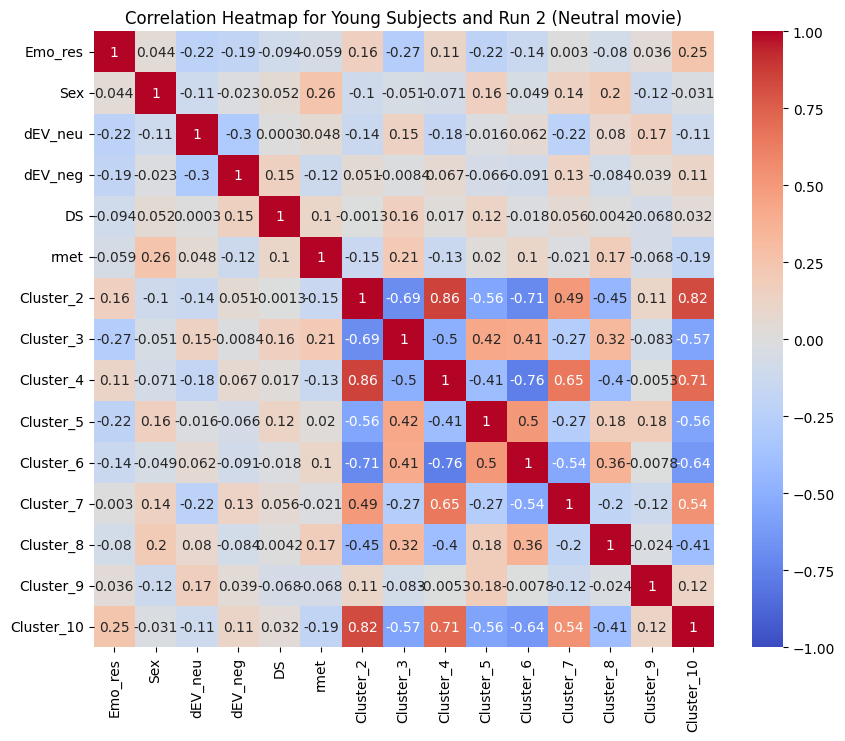

In [102]:
csv_path = "C:\\Users\\oddafo\\Downloads\\Combined_Beh_Cognitive.csv"
csv_ids_path = "Dummy Test Data\\Included_subjects_Young.csv"

csv_ids = pd.read_csv(csv_ids_path)
res_scores, all_scores = extract_res_scores_from_csv(csv_path)
print(f"Size of res_scores: {res_scores.shape} and all_scores: {all_scores.shape}")

# Remove the rows from res_scores that are not in csv_ids
res_scores = res_scores[res_scores["Subject"].isin(csv_ids["Subject"])]
all_scores = all_scores[all_scores["Subject"].isin(csv_ids["Subject"])]
print(f"Size of res_scores: {res_scores.shape} and all_scores: {all_scores.shape}")

# Reindex the DataFrame after filtering
res_scores = res_scores.reset_index(drop=True)
all_scores = all_scores.reset_index(drop=True)

# Load all cluster labels for the young subjects run 2, and extract the ones that match the subjects in res_scores
start_string = "Clusters\\DCEC_400x400_72_Y_subjects_run2_"
df_scores = extract_all_cluster_labels_from_txt(start_string=start_string, df=res_scores, clusters_range=range(2, 11))
df = extract_all_cluster_labels_from_txt(start_string=start_string, df=all_scores, clusters_range=range(2, 11))

print(df_scores)

plot_correlation_heatmap(df_scores, plt_title="Correlation Heatmap for Young Subjects and Run 2 (Neutral movie)")


In [106]:
# Do ANOVA
import scipy.stats as stats

cluster_col = df_scores["Cluster_4"]  # Replace with the actual cluster column you want to analyze
variable = "Q8IRI"  # Replace with the actual variable you want to analyze

groups = [group[variable].values for _, group in df.groupby(cluster_col)]
    
# ANOVA
F, p = stats.f_oneway(*groups)

# Compute eta squared
grand_mean = df[variable].mean()

ss_between = sum(
    len(g) * (g.mean() - grand_mean) ** 2
    for g in groups
)

ss_total = sum((df[variable] - grand_mean) ** 2)

eta_sq = ss_between / ss_total

print(f"ANOVA results for {variable} across clusters:")
print(f"Explained variance: {eta_sq:.4f}, p-value: {p:.4f}")

ANOVA results for Q8IRI across clusters:
Explained variance: 0.0433, p-value: 0.4006


In [107]:
# Do MANOVA
from statsmodels.multivariate.manova import MANOVA

manova = MANOVA.from_formula('dEV_neu + Q8IRI ~ Cluster_4', data=df)

print(manova.mv_test())
# Wilks' lambda: Is the proportion of variance in the dependent variables that is not explained by the independent variable (clusters). A lower value indicates a stronger effect 
#               of the clusters on the dependent variables. Good values is 0,5 or lower. [0, 1] 
# Pillai's trace: Measures the proportion of variance in the dependent variables that is explained by the independent variable. A higher value indicates a stronger effect of the 
#               clusters on the dependent variables. Good values are 0,5 or higher. [0, 1]
# Hotelling-Lawley trace: Similar to Pillai's trace but can be more sensitive to differences in group means. A higher value indicates a stronger effect of the clusters on the 
#               dependent variables. [0, inf]
# Roy's largest root: The largest eigenvalue of the hypothesis sum of squares and cross-products matrix divided by the error sum of squares and cross-products matrix. A higher 
#               value indicates a stronger effect of the clusters on the dependent variables. [0, inf]
# Pr > F: The p-value associated with the test statistic. A lower value indicates that the observed differences between clusters are unlikely to have occurred by chance. A common
#               threshold for significance is 0,05.

                  Multivariate linear model
                                                              
--------------------------------------------------------------
       Intercept         Value  Num DF  Den DF F Value  Pr > F
--------------------------------------------------------------
          Wilks' lambda  0.0693 2.0000 67.0000 450.0920 0.0000
         Pillai's trace  0.9307 2.0000 67.0000 450.0920 0.0000
 Hotelling-Lawley trace 13.4356 2.0000 67.0000 450.0920 0.0000
    Roy's greatest root 13.4356 2.0000 67.0000 450.0920 0.0000
--------------------------------------------------------------
                                                              
--------------------------------------------------------------
         Cluster_4        Value  Num DF  Den DF F Value Pr > F
--------------------------------------------------------------
            Wilks' lambda 0.9407 2.0000 67.0000  2.1106 0.1292
           Pillai's trace 0.0593 2.0000 67.0000  2.1106 0.1292
   Hotellin

In [116]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from statsmodels.multivariate.manova import MANOVA


def _eta_squared(df, cluster_col, variable):
    temp = df[[cluster_col, variable]].dropna()
    groups = [g[variable].values for _, g in temp.groupby(cluster_col)]

    if len(groups) < 2:
        return np.nan, np.nan

    try:
        f_stat, p_val = stats.f_oneway(*groups)
    except Exception as e:
        print(f"ANOVA failed for {variable}: {e}")
        return np.nan, np.nan

    grand_mean = temp[variable].mean()
    ss_between = sum(len(g) * (np.mean(g) - grand_mean) ** 2 for g in groups)
    ss_total = np.sum((temp[variable] - grand_mean) ** 2)

    eta_sq = ss_between / ss_total if ss_total != 0 else np.nan
    return eta_sq, p_val


def _manova_pillai_p(df, cluster_col, variables):
    temp = df[[cluster_col] + variables].dropna()

    if len(variables) == 0:
        print("No variables left for MANOVA")
        return np.nan

    if len(temp) == 0:
        print(f"MANOVA failed: no rows left after dropna for variables {variables}")
        return np.nan

    if temp[cluster_col].nunique() < 2:
        print(f"MANOVA failed: fewer than 2 clusters remain for variables {variables}")
        return np.nan

    # remove constant variables
    nonconstant_vars = [v for v in variables if temp[v].nunique() > 1]
    if len(nonconstant_vars) == 0:
        print(f"MANOVA failed: all variables constant for {variables}")
        return np.nan

    try:
        formula = " + ".join(nonconstant_vars) + f" ~ C({cluster_col})"
        result = MANOVA.from_formula(formula, data=temp).mv_test()

        stats_table = result.results[f"C({cluster_col})"]["stat"]
        return float(stats_table.loc["Pillai's trace", "Pr > F"])

    except Exception as e:
        print(f"MANOVA failed for variables {variables}: {e}")
        return np.nan


def rank_variable_importance(df, cluster_col, variables=None):
    if variables is None:
        variables = [c for c in df.columns if c != cluster_col]

    variables = [v for v in variables if v != cluster_col]

    full_p = _manova_pillai_p(df, cluster_col, variables)

    rows = []
    for var in variables:
        eta_sq, anova_p = _eta_squared(df, cluster_col, var)

        reduced_vars = [v for v in variables if v != var]
        reduced_p = _manova_pillai_p(df, cluster_col, reduced_vars)

        delta_p = reduced_p - full_p if pd.notna(full_p) and pd.notna(reduced_p) else np.nan

        rows.append({
            "variable": var,
            "eta_squared": eta_sq,
            "anova_p": anova_p,
            "full_manova_p": full_p,
            "reduced_manova_p": reduced_p,
            "delta_manova_p": delta_p,
        })

    out = pd.DataFrame(rows)
    return out.sort_values(by=["eta_squared", "delta_manova_p"], ascending=[False, False]).reset_index(drop=True)

In [117]:
columns = df.columns.tolist()
columns.remove("Subject")
columns.remove("Group") 
columns.remove("Gender")
columns.remove("Handedness")  # Remove non-behavioural variables
columns.remove("Medicine")  # Remove non-behavioural variables
columns.remove("Cluster_2")  # Remove other cluster columns
columns.remove("Cluster_3")  # Remove other cluster columns
columns.remove("Cluster_4")  # Remove other cluster columns
columns.remove("Cluster_5")  # Remove other cluster columns
columns.remove("Cluster_6")  # Remove other cluster columns
columns.remove("Cluster_7")  # Remove other cluster columns
columns.remove("Cluster_8")  # Remove other cluster columns
columns.remove("Cluster_9")  # Remove other cluster columns
columns.remove("Cluster_10")  # Remove other cluster columns
print(columns)

importance_df = rank_variable_importance(df, cluster_col="Cluster_4", variables=columns)

print(importance_df)
print(df.columns)

['Age', 'Order', 'Sex', 'Relationshipstatus', 'Avg_Sleep', 'EnglishYearsSpeaking', 'YearsEducation', 'PsychDiagnosis', 'NeuroImpairment', 'EV_base', 'EV_neu', 'EV_neg', 'ER_base', 'ER_neu', 'ER_neg', 'dEV_neu', 'dEV_neg', 'dER_neu', 'dER_neg', 'Q1_DASSDepression', 'Q1_DASSAnxiety', 'Q1_DASSStress', 'Q2_DERSScore', 'Q2_DERSNONACCEPT', 'Q2_DERSGOALS', 'Q2_DERSIMPULSE', 'Q2_DERSAWARENESS', 'Q2_DERSSTRATEGIES', 'Q2_DERSCLARITY', 'Q3_GHQ28Score', 'Q3_GHQ28SomaticSymptoms', 'Q3_GHQ28Anxiety_Insomnia', 'Q3SocialDysfunction', 'Q3SevereDepression', 'Q4Depression', 'Q4Anxiety', 'Q5CD_RISC', 'Q6PSS', 'Q7F1', 'Q7F2', 'Q7Unifactorial', 'Q8IRI', 'Q9Perspective', 'Q8Fantasy', 'Q8Cog_em', 'Q8empathic_concern', 'Q8personal_distress', 'Q8emo_em', 'Q9StateAnxiety', 'Q9TraitAnxiety', 'hd_neutral', 'hd_negative', 'ACC', 'spanForward', 'spanBackwards', 'DS', 'TIV', 'GM', 'WM', 'CSF', 'mean_accuracy', 'mean_RT', 'rmet', 'Emo_res', 'rSFA', 'rCMA', 'rBLA', 'lSFA', 'lCMA', 'lBLA', 'm1_tISC', 'm2_tISC', 'Cogniti

c:\Users\oddafo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\multivariate\multivariate_ols.py:196: RuntimeWarning: invalid value encountered in power
  lmd = np.power(lmd, 1 / t)
c:\Users\oddafo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\multivariate\multivariate_ols.py:196: RuntimeWarning: invalid value encountered in power
  lmd = np.power(lmd, 1 / t)
c:\Users\oddafo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\multivariate\multivariate_ols.py:196: RuntimeWarning: invalid value encountered in power
  lmd = np.power(lmd, 1 / t)
c:\Users\oddafo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\multivariate\multivariate_ols.py:196: RuntimeWarning: invalid value encountered in power
  lmd = np.power(lmd, 1 / t)
c:\Users\oddafo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\multivariate\multivariate_ols.py:196: RuntimeWarning: invalid value encountered in power
  lmd = n

              variable  eta_squared   anova_p  full_manova_p  \
0          hd_negative     0.201416  0.001856            NaN   
1           hd_neutral     0.153436  0.011326            NaN   
2        Q9Perspective     0.133903  0.022716            NaN   
3   Q3SevereDepression     0.133564  0.022987            NaN   
4   Q8empathic_concern     0.086160  0.112049            NaN   
..                 ...          ...       ...            ...   
68      Q9StateAnxiety     0.004568  0.959183            NaN   
69             ER_base     0.002777  0.979984            NaN   
70                  DS     0.001835  0.989053            NaN   
71       spanBackwards     0.001745  0.989835            NaN   
72  Relationshipstatus     0.000768  0.996978            NaN   

    reduced_manova_p  delta_manova_p  
0                NaN             NaN  
1                NaN             NaN  
2                NaN             NaN  
3                NaN             NaN  
4                NaN             NaN

c:\Users\oddafo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\multivariate\multivariate_ols.py:196: RuntimeWarning: invalid value encountered in power
  lmd = np.power(lmd, 1 / t)


In [63]:
print(df.shape)
print(df["Cluster_5"].value_counts(dropna=False))

for col in ["rmet", "Emo_res", "dEV_neu", "dEV_neg", "dER_neu", "dER_neg", "Q8IRI"]:
    temp = df[["Cluster_5", col]].dropna()
    print(f"{col}: rows after dropna = {len(temp)}, clusters = {temp['Cluster_5'].nunique()}, std = {temp[col].std()}")

print(temp.head())

(71, 86)
Cluster_5
4    19
0    18
2    14
1    14
3     6
Name: count, dtype: int64
rmet: rows after dropna = 68, clusters = 5, std = 4.1348005929924065
Emo_res: rows after dropna = 71, clusters = 5, std = 20.381456061118158
dEV_neu: rows after dropna = 71, clusters = 5, std = 1.3450856973439256
dEV_neg: rows after dropna = 71, clusters = 5, std = 1.9757076006177716
dER_neu: rows after dropna = 71, clusters = 5, std = 1.417198188054639
dER_neg: rows after dropna = 71, clusters = 5, std = 1.888224656688062
Q8IRI: rows after dropna = 71, clusters = 5, std = 13.063935027025433
   Cluster_5  Q8IRI
0          2     88
1          2     49
2          1     76
3          1     62
4          4     76


In [45]:
from statsmodels.multivariate.manova import MANOVA

vars_ = ["rmet", "Emo_res", "dEV_neu", "dEV_neg", "dER_neu", "dER_neg", "Q8IRI"]
temp = df[["Cluster_5"] + vars_].dropna()

model = MANOVA.from_formula("rmet + Emo_res + dEV_neu + dEV_neg + dER_neu + dER_neg + Q8IRI ~ Cluster_5", data=temp)
print(model.mv_test())

                        Multivariate linear model
                                                                         
-------------------------------------------------------------------------
       Intercept               Value         Num DF Den DF F Value Pr > F
-------------------------------------------------------------------------
          Wilks' lambda               0.0000 7.0000 0.0000  0.0000    nan
         Pillai's trace               1.0000 7.0000 0.0000  0.0000    nan
 Hotelling-Lawley trace 600479950316065.1250 7.0000 0.0000  0.0000    nan
    Roy's greatest root 600479950316065.1250 7.0000 0.0000  0.0000    nan
-------------------------------------------------------------------------
                                                                         
-------------------------------------------------------------------------
         Cluster_5              Value        Num DF Den DF F Value Pr > F
--------------------------------------------------------------

In [55]:
def split_csv_by_subject_prefix(
    csv_path,
    output_file_1,
    output_file_2,
    subject_col="Subject",
    prefixes=("11", "12")
):
    df = pd.read_csv(csv_path)

    if subject_col not in df.columns:
        raise ValueError(f"Column '{subject_col}' not found in {csv_path}")

    subj = (
        df[subject_col]
        .astype(str)
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)  # handles values like 11070.0
    )

    first_two = subj.str[:2]

    df_1 = df[first_two == str(prefixes[0])].copy()
    df_2 = df[first_two == str(prefixes[1])].copy()

    df_1.to_csv(output_file_1, index=False)
    df_2.to_csv(output_file_2, index=False)

    print(f"Saved {len(df_1)} rows to: {output_file_1} (prefix {prefixes[0]})")
    print(f"Saved {len(df_2)} rows to: {output_file_2} (prefix {prefixes[1]})")

    return df_1, df_2

csv_path = "Dummy Test Data\\Included subjects_clean.csv"

split_csv_by_subject_prefix(
    csv_path,
    output_file_1="Dummy Test Data\\Included_subjects_Young.csv",
    output_file_2="Dummy Test Data\\Included_subjects_Old.csv",
    subject_col="Subject",
    prefixes=("11", "12")
)


Saved 71 rows to: Dummy Test Data\Included_subjects_Young.csv (prefix 11)
Saved 68 rows to: Dummy Test Data\Included_subjects_Old.csv (prefix 12)


(    Subject
 0     11001
 1     11004
 2     11009
 3     11012
 4     11018
 ..      ...
 66    11211
 67    11213
 68    11214
 69    11215
 70    11216
 
 [71 rows x 1 columns],
      Subject
 71     12008
 72     12010
 73     12011
 74     12015
 75     12017
 ..       ...
 134    12295
 135    12298
 136    12301
 137    12320
 138    12334
 
 [68 rows x 1 columns])

In [83]:
import pandas as pd
 
# Combine two csv files 
csv1 = "C:\\Users\\oddafo\\Downloads\\Beh.csv"
csv2 = "C:\\Users\\oddafo\\Downloads\\Cognitive_PC.csv"
df1 = pd.read_csv(csv1)
df2 = pd.read_csv(csv2, sep=";")  # Assuming the second file is tab-separated
print(df2.head())
# Change the name of the subjects in df2 to match df1 from sub-xxxx to xxxx
df2["Subject"] = df2["Sub"].astype(str).str.strip().str.replace(r"^sub-", "", regex=True).str.replace(r"\.0$", "", regex=True)
# Change the type of Subject in df2
df2["Subject"] = df2["Subject"].astype(int)
df2.drop(columns=["Sub"], inplace=True)
# Change the "," in the Cognitive_PC column to "." and convert to numeric
df2["Cognitive_PC"] = df2["Cognitive_PC"].astype(str).str.replace(",", ".", regex=False)
# Change the type of Cognitive_PC in df2 to numeric, coercing errors to NaN
df2["Cognitive_PC"] = pd.to_numeric(df2["Cognitive_PC"], errors="coerce")
# Merge the two dataframes on the Subject column, keeping only rows that have a match in both dataframes
combined_df = pd.merge(df1, df2, on="Subject", how="inner")
print(combined_df.shape)
# Save the combined dataframe to a new csv file
combined_df.to_csv("Combined_Beh_Cognitive.csv", index=False)


         Sub Cognitive_PC
0  sub-11001      0,55264
1  sub-11004       1,7972
2  sub-11009      -0,5437
3  sub-11012      1,12664
4  sub-11018      0,99605
(138, 78)


In [123]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.multivariate.manova import MANOVA


def _eta_squared(df, cluster_col, variable):
    temp = df[[cluster_col, variable]].dropna()

    model = ols(f"{variable} ~ C({cluster_col})", data=temp).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)

    ss_between = anova_table.loc[f"C({cluster_col})", "sum_sq"]
    ss_total = anova_table["sum_sq"].sum()

    eta_sq = ss_between / ss_total if ss_total != 0 else np.nan
    p_val = anova_table.loc[f"C({cluster_col})", "PR(>F)"]

    return eta_sq, p_val


def _manova_p(df, cluster_col, variables):
    temp = df[[cluster_col] + variables].dropna()

    # Remove constant variables
    variables = [v for v in variables if temp[v].nunique() > 1]

    if len(variables) == 0 or temp[cluster_col].nunique() < 2:
        return np.nan

    try:
        formula = " + ".join(variables) + f" ~ C({cluster_col})"
        result = MANOVA.from_formula(formula, data=temp).mv_test()

        stats_table = result.results[f"C({cluster_col})"]["stat"]

        # Use Pillai's trace p-value
        return float(stats_table.loc["Pillai's trace", "Pr > F"])

    except Exception:
        return np.nan


def rank_variable_importance(df, cluster_col, variables):
    """
    Returns a dataframe ranking variables by:
    - eta_squared (explained variance)
    - delta_manova_p (contribution to multivariate separation)
    """

    # Full model p-value
    full_p = _manova_p(df, cluster_col, variables)

    rows = []

    for var in variables:
        eta_sq, anova_p = _eta_squared(df, cluster_col, var)

        # Reduced model (remove this variable)
        reduced_vars = [v for v in variables if v != var]
        reduced_p = _manova_p(df, cluster_col, reduced_vars)

        # Δ p-value
        if pd.notna(full_p) and pd.notna(reduced_p):
            delta_p = reduced_p - full_p
        else:
            delta_p = np.nan

        rows.append({
            "variable": var,
            "eta_squared": eta_sq,
            "explained_%": eta_sq * 100 if pd.notna(eta_sq) else np.nan,
            "anova_p": anova_p,
            "full_manova_p": full_p,
            "reduced_manova_p": reduced_p,
            "delta_manova_p": delta_p
        })

    result_df = pd.DataFrame(rows)

    # Rank by importance
    result_df = result_df.sort_values(
        by=["eta_squared", "delta_manova_p"],
        ascending=[False, False]
    ).reset_index(drop=True)

    return result_df


def run_full_analysis(df, cluster_col, variables):
    """
    Runs:
    1. MANOVA (overall test)
    2. Variable importance ranking
    """

    print("=== MANOVA (overall effect of clusters) ===")
    manova = MANOVA.from_formula(
        " + ".join(variables) + f" ~ C({cluster_col})",
        data=df.dropna()
    )
    print(manova.mv_test())

    print("\n=== Variable importance ===")
    importance_df = rank_variable_importance(df, cluster_col, variables)
    print(importance_df)

    return importance_df

In [124]:
run_full_analysis(df, cluster_col="Cluster_4", variables=columns)

=== MANOVA (overall effect of clusters) ===


LinAlgError: Singular matrix

In [125]:
"""
cluster_separability.py
=======================
Evaluate how much of the clustering separation can be explained by
behavioural variables — both individually and jointly — and rank their
importance.

Usage
-----
    from cluster_separability import ClusterSeparabilityAnalyzer

    analyzer = ClusterSeparabilityAnalyzer(labels, scores_df)
    results  = analyzer.run()
    analyzer.report(results)

Inputs
------
    labels      : array-like of int/str, shape (n_samples,)
    scores_df   : pd.DataFrame of shape (n_samples, n_variables)

Three complementary analyses
-----------------------------
1. LDA — measures *joint* separability (all variables together).
   Returns: % variance explained per discriminant axis, Wilks' λ.

2. Permutation importance — ranks variables by how much cluster
   separability drops when each is randomly shuffled.
   Returns: mean importance ± std for each variable.

3. Pairwise η² (eta-squared) — for each variable, measures effect size
   between every pair of clusters (one-way ANOVA η²).
   Returns: variable × cluster-pair matrix of effect sizes.

NaN handling
------------
Each analysis treats missingness in the most appropriate way:

* Pairwise η²  — uses all available (non-NaN) observations per variable
  independently, so no data is discarded and no imputation is applied.

* LDA and permutation importance — require a complete feature matrix.
  Missing values are filled with the per-feature *median* (robust to
  outliers). For every variable that has any missingness a binary
  indicator column (``<name>_missing``) is added to the matrix so that
  the pattern of missingness can itself contribute to separability.
  A missingness summary is printed at run-time and stored in results.
"""

import numpy as np
import pandas as pd
from itertools import combinations

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score
from scipy import stats


# ─────────────────────────────────────────────────────────────────────────────
# Main analyser
# ─────────────────────────────────────────────────────────────────────────────

class ClusterSeparabilityAnalyzer:
    """
    Parameters
    ----------
    labels      : array-like, shape (n_samples,)
    scores_df   : pd.DataFrame, shape (n_samples, n_variables)
    n_permutations : int
        Number of permutations for the importance estimate. 100 is fast;
        500+ is more stable for small samples.
    cv_folds    : int
        Cross-validation folds for the permutation-importance step.
    random_state : int
    """

    def __init__(
        self,
        labels,
        scores_df: pd.DataFrame,
        n_permutations: int = 200,
        cv_folds: int = 5,
        random_state: int = 42,
    ):
        self.labels = np.asarray(labels)
        self.X = scores_df.copy()
        self.feature_names = list(scores_df.columns)
        self.n_permutations = n_permutations
        self.cv_folds = cv_folds
        self.random_state = random_state

        self._le = LabelEncoder()
        self.y = self._le.fit_transform(self.labels)
        self.cluster_names = list(self._le.classes_)
        self.n_clusters = len(self.cluster_names)

        # Built by _prepare_imputed(); available after run()
        self.nan_summary: pd.DataFrame | None = None

    # ─── public ──────────────────────────────────────────────────────────────

    def run(self) -> dict:
        """Run all three analyses and return a results dict."""
        # Imputed matrix used by LDA and permutation importance
        X_imp, imp_feature_names = self._prepare_imputed()

        if self.nan_summary is not None and self.nan_summary["n_missing"].sum() > 0:
            print("NaN summary (median imputation applied for LDA / permutation):")
            print(self.nan_summary[self.nan_summary["n_missing"] > 0].to_string(index=False))
            print()

        print("Running LDA (joint separability)…")
        lda_results = self._lda_analysis(X_imp, imp_feature_names)

        print("Running permutation importance (individual + joint)…")
        perm_results = self._permutation_importance(X_imp, imp_feature_names)

        print("Computing pairwise η² effect sizes…")
        eta_results = self._pairwise_eta_squared()

        return {
            "lda": lda_results,
            "permutation_importance": perm_results,
            "pairwise_eta2": eta_results,
            "nan_summary": self.nan_summary,
        }

    def report(self, results: dict, top_n: int = None) -> None:
        """Print a human-readable summary."""
        top_n = top_n or len(self.feature_names)

        # ── 0. NaN summary ──
        nan_df = results.get("nan_summary")
        if nan_df is not None and nan_df["n_missing"].sum() > 0:
            print("\n" + "=" * 60)
            print("0. MISSINGNESS SUMMARY")
            print("=" * 60)
            print("   Variables with NaNs (median-imputed; indicator col added):")
            affected = nan_df[nan_df["n_missing"] > 0]
            for row in affected.itertuples():
                print(f"   {row.variable:<30} {row.n_missing:>5} missing "
                      f"({row.pct_missing:5.1f}%)")
            print()

        # ── 1. LDA ──
        lda = results["lda"]
        print("\n" + "=" * 60)
        print("1. JOINT SEPARABILITY  (Linear Discriminant Analysis)")
        print("=" * 60)
        print(f"   Cross-validated balanced accuracy : "
              f"{lda['cv_balanced_accuracy']:.3f}")
        print(f"   Wilks' λ (smaller = more separable): "
              f"{lda['wilks_lambda']:.4f}")
        print(f"   p-value (approx. chi-sq test)       : "
              f"{lda['wilks_pvalue']:.4e}")
        print("\n   Discriminant axes — variance explained:")
        for i, (ev, cev) in enumerate(
            zip(lda["explained_variance_ratio"], lda["cumulative_variance"]), 1
        ):
            bar = "█" * int(ev * 40)
            print(f"   LD{i}  {ev:5.1%}  (cumul. {cev:5.1%})  {bar}")

        # ── 2. Permutation importance ──
        pi = results["permutation_importance"]
        ranking = pi["ranking"]  # DataFrame sorted by mean importance
        print("\n" + "=" * 60)
        print("2. VARIABLE IMPORTANCE  (permutation, Random Forest)")
        print("=" * 60)
        print(f"   {'Rank':<5} {'Variable':<30} {'Importance':>10}  {'±Std':>8}")
        print("   " + "-" * 56)
        for rank, row in enumerate(ranking.head(top_n).itertuples(), 1):
            bar = "█" * max(1, int(row.mean_importance * 50))
            print(f"   {rank:<5} {row.variable:<30} "
                  f"{row.mean_importance:>10.4f}  "
                  f"{row.std_importance:>8.4f}  {bar}")

        # ── 3. Pairwise η² ──
        eta = results["pairwise_eta2"]
        print("\n" + "=" * 60)
        print("3. PAIRWISE EFFECT SIZES  (η² per cluster pair)")
        print("=" * 60)
        print(eta["summary"].to_string())
        print("\n   Full matrix (rows = variables, cols = cluster pairs):")
        print(eta["matrix"].round(3).to_string())

    # ─── private ─────────────────────────────────────────────────────────────

    def _prepare_imputed(self):
        """
        Build the complete feature matrix needed by LDA and permutation
        importance.

        Steps
        -----
        1. Record missingness per variable.
        2. For each variable with any NaN, add a binary indicator column
           ``<name>_missing`` (1 = was NaN, 0 = observed).
        3. Fill NaNs with the per-feature median (computed on observed
           values only, so no data leakage from test folds).

        Returns
        -------
        X_imp : np.ndarray, shape (n_samples, n_features_augmented)
        imp_feature_names : list[str]
        """
        df = self.X.copy()
        n = len(df)

        nan_counts = df.isna().sum()
        self.nan_summary = pd.DataFrame({
            "variable": self.feature_names,
            "n_missing": nan_counts.values,
            "pct_missing": (nan_counts.values / n * 100),
        })

        indicator_cols = {}
        for col in self.feature_names:
            if df[col].isna().any():
                indicator_cols[f"{col}_missing"] = df[col].isna().astype(float)

        # Median imputation
        for col in self.feature_names:
            if df[col].isna().any():
                median_val = df[col].median()
                df[col] = df[col].fillna(median_val)

        # Append indicator columns
        for ind_name, ind_series in indicator_cols.items():
            df[ind_name] = ind_series.values

        imp_feature_names = list(df.columns)
        return df.values.astype(float), imp_feature_names

    def _lda_analysis(self, X_imp: np.ndarray, imp_feature_names: list) -> dict:
        y = self.y

        lda = LinearDiscriminantAnalysis(solver="svd", store_covariance=True)
        lda.fit(X_imp, y)

        # Explained variance per axis
        evr = lda.explained_variance_ratio_
        cumulative = np.cumsum(evr)

        # Cross-validated balanced accuracy
        cv = StratifiedKFold(
            n_splits=self.cv_folds, shuffle=True,
            random_state=self.random_state
        )
        ba_scores = []
        for train, test in cv.split(X_imp, y):
            lda_cv = LinearDiscriminantAnalysis(solver="svd")
            lda_cv.fit(X_imp[train], y[train])
            ba_scores.append(
                balanced_accuracy_score(y[test], lda_cv.predict(X_imp[test]))
            )
        cv_ba = float(np.mean(ba_scores))

        # Wilks' λ approximation
        wilks_lambda, p_value = self._wilks_test(X_imp, y, lda)

        return {
            "explained_variance_ratio": evr.tolist(),
            "cumulative_variance": cumulative.tolist(),
            "cv_balanced_accuracy": cv_ba,
            "wilks_lambda": wilks_lambda,
            "wilks_pvalue": p_value,
            "lda_object": lda,
            "feature_names_used": imp_feature_names,
        }

    def _permutation_importance(self, X_imp: np.ndarray, imp_feature_names: list) -> dict:
        y = self.y

        # Fit a Random Forest — it handles non-linearity better than LDA,
        # so permutation importance gives a fairer per-variable picture.
        rf = RandomForestClassifier(
            n_estimators=400,
            random_state=self.random_state,
            n_jobs=-1,
        )
        rf.fit(X_imp, y)

        result = permutation_importance(
            rf, X_imp, y,
            n_repeats=self.n_permutations,
            random_state=self.random_state,
            scoring="balanced_accuracy",
            n_jobs=-1,
        )

        ranking = pd.DataFrame({
            "variable": imp_feature_names,
            "mean_importance": result.importances_mean,
            "std_importance": result.importances_std,
        }).sort_values("mean_importance", ascending=False).reset_index(drop=True)

        return {
            "ranking": ranking,
            "raw_importances": result.importances,   # shape (n_features, n_repeats)
            "rf_object": rf,
            "feature_names_used": imp_feature_names,
        }

    def _pairwise_eta_squared(self) -> dict:
        """
        For each variable and each pair of clusters, compute η² from a
        one-way ANOVA restricted to those two clusters.

        η² = SS_between / SS_total
        Interpretation: proportion of variance in that variable accounted
        for by cluster membership (effect size).

        NaN handling: each variable uses only its observed (non-NaN) rows,
        independently of other variables. No imputation is applied here.
        The effective N per cell is recorded so you can spot low-data pairs.
        """
        pairs = list(combinations(range(self.n_clusters), 2))
        pair_labels = [
            f"{self.cluster_names[a]} vs {self.cluster_names[b]}"
            for a, b in pairs
        ]

        matrix = pd.DataFrame(
            index=self.feature_names,
            columns=pair_labels,
            dtype=float,
        )
        pval_matrix = pd.DataFrame(
            index=self.feature_names,
            columns=pair_labels,
            dtype=float,
        )

        for feat in self.feature_names:
            x = self.X[feat].values
            for (a, b), col in zip(pairs, pair_labels):
                mask_a = (self.y == a) & ~np.isnan(x.astype(float))
                mask_b = (self.y == b) & ~np.isnan(x.astype(float))
                xa = x[mask_a].astype(float)
                xb = x[mask_b].astype(float)

                # Need at least one observation per group
                if len(xa) == 0 or len(xb) == 0:
                    matrix.loc[feat, col] = np.nan
                    pval_matrix.loc[feat, col] = np.nan
                    continue

                combined = np.concatenate([xa, xb])
                grand_mean = combined.mean()
                ss_total = np.sum((combined - grand_mean) ** 2)

                if ss_total == 0:
                    eta2 = 0.0
                    p_val = 1.0
                else:
                    ss_between = (
                        len(xa) * (xa.mean() - grand_mean) ** 2
                        + len(xb) * (xb.mean() - grand_mean) ** 2
                    )
                    eta2 = float(ss_between / ss_total)
                    _, p_val = stats.f_oneway(xa, xb)

                matrix.loc[feat, col] = eta2
                pval_matrix.loc[feat, col] = p_val

        # Summary: for each variable, mean η² across all pairs (ignoring NaN pairs)
        summary = pd.DataFrame({
            "variable": self.feature_names,
            "mean_eta2": matrix.mean(axis=1).values,
            "max_eta2": matrix.max(axis=1).values,
            "best_pair": matrix.idxmax(axis=1).values,
        }).sort_values("mean_eta2", ascending=False).reset_index(drop=True)

        return {
            "matrix": matrix,
            "pvalue_matrix": pval_matrix,
            "summary": summary,
        }

    @staticmethod
    def _wilks_test(X, y, lda):
        """
        Approximate Wilks' λ and a chi-squared p-value.
        λ = product of (1 / (1 + eigenvalue)) across all discriminant axes.
        """
        try:
            # sklearn stores scalings_ as eigenvectors; recompute eigenvalues
            # from the ratio of between-class to within-class variance
            classes = np.unique(y)
            n = len(y)
            p = X.shape[1]
            k = len(classes)

            overall_mean = X.mean(axis=0)
            S_W = np.zeros((p, p))
            S_B = np.zeros((p, p))

            for c in classes:
                Xc = X[y == c]
                nc = len(Xc)
                mean_c = Xc.mean(axis=0)
                diff_c = mean_c - overall_mean
                S_B += nc * np.outer(diff_c, diff_c)
                Xc_centered = Xc - mean_c
                S_W += Xc_centered.T @ Xc_centered

            # eigenvalues of S_W^{-1} S_B
            try:
                evals = np.linalg.eigvals(
                    np.linalg.lstsq(S_W, S_B, rcond=None)[0]
                ).real
                evals = evals[evals > 1e-10]
                wilks = float(np.prod(1.0 / (1.0 + evals)))
            except np.linalg.LinAlgError:
                return float("nan"), float("nan")

            # Bartlett chi-squared approximation
            df = p * (k - 1)
            chi2 = -(n - 1 - (p + k) / 2) * np.log(wilks)
            p_value = float(1 - stats.chi2.cdf(chi2, df))
            return wilks, p_value

        except Exception:
            return float("nan"), float("nan")


# ─────────────────────────────────────────────────────────────────────────────
# Quick demo — replace with your own data
# ─────────────────────────────────────────────────────────────────────────────
labels = df["Cluster_4"]  # Replace with your actual cluster labels
scores_df = df[columns]  # Replace with your actual behavioural variables

analyzer = ClusterSeparabilityAnalyzer(labels, scores_df)
results = analyzer.run()
analyzer.report(results)

NaN summary (median imputation applied for LDA / permutation):
            variable  n_missing  pct_missing
EnglishYearsSpeaking         14    20.000000
       mean_accuracy          3     4.285714
             mean_RT          3     4.285714
                rmet          3     4.285714
        Cognitive_PC          4     5.714286

Running LDA (joint separability)…
Running permutation importance (individual + joint)…
Computing pairwise η² effect sizes…

0. MISSINGNESS SUMMARY
   Variables with NaNs (median-imputed; indicator col added):
   EnglishYearsSpeaking              14 missing ( 20.0%)
   mean_accuracy                      3 missing (  4.3%)
   mean_RT                            3 missing (  4.3%)
   rmet                               3 missing (  4.3%)
   Cognitive_PC                       4 missing (  5.7%)


1. JOINT SEPARABILITY  (Linear Discriminant Analysis)
   Cross-validated balanced accuracy : 0.264
   Wilks' λ (smaller = more separable): 0.0001
   p-value (approx. chi-